In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode

load_dotenv()


class ChildState(TypedDict):
    messages: Annotated[list, add_messages]


# These belong at module level, not inside the TypedDict
search_tool = TavilySearch(max_results=2)
tools = [search_tool]

llm = ChatGroq(model="llama-3.1-8b-instant")
llm_with_tools = llm.bind_tools(tools=tools)


def agent(state: ChildState):
    return {
        "messages": [llm_with_tools.invoke(state["messages"])],
    }


def tools_router(state: ChildState):  # also fixed typo below
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "tools"
    else:
        return END


tool_node = ToolNode(tools=tools)

subgraph = StateGraph(ChildState)

subgraph.add_node("agent", agent)
subgraph.add_node("tools", tool_node)  # name should match what tools_router returns
subgraph.set_entry_point("agent")

subgraph.add_conditional_edges("agent", tools_router)
subgraph.add_edge("tools", "agent")

search_app = subgraph.compile()

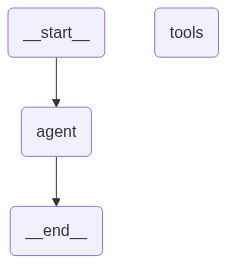

In [3]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        search_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

Case 1: Shared Schema

In [5]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_core.messages import HumanMessage

# Define parent graph with the same schema
class ParentState(TypedDict):
    messages: Annotated[list, add_messages]

# Create parent graph
parent_graph = StateGraph(ParentState)

# Add the subgraph as a node
parent_graph.add_node("search_agent", search_app)

# Connect the flow
parent_graph.add_edge(START, "search_agent")
parent_graph.add_edge("search_agent", END)

# Compile parent graph
parent_app = parent_graph.compile()

# Run the parent graph
result = parent_app.invoke({"messages": [HumanMessage(content="How is the weather in LAhore?")]})
result

{'messages': [HumanMessage(content='How is the weather in LAhore?', additional_kwargs={}, response_metadata={}, id='f4cbad6f-b8c6-492b-9241-3f541bb587a0'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gdcvphpaz', 'function': {'arguments': '{"query":"Lahore weather","search_depth":"basic","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 1691, 'total_tokens': 1723, 'completion_time': 0.044719551, 'completion_tokens_details': None, 'prompt_time': 0.080299633, 'prompt_tokens_details': {'cached_tokens': 512}, 'queue_time': 0.005261822, 'total_time': 0.125019184}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc99d-6642-77d2-816e-485b35ddf9eb-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Lahore weather', 'search_de

Case 2: Diffrent Schema 

In [6]:
from typing import TypedDict, Annotated, Dict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage

# Define parent graph with different schema
class QueryState(TypedDict):
    query: str
    response: str

def search_agent(state: QueryState) -> Dict:
   # Transform from parent schema to subgraph schema
    subgraph_input = {
        "messages": [HumanMessage(content=state["query"])]
    }
     # Invoke the subgraph
    subgraph_result = search_app.invoke(subgraph_input)
    
    # Transform response back to parent schema
    assistant_message = subgraph_result["messages"][-1]
    return {"response": assistant_message.content}

# Create parent graph
parent_graph = StateGraph(QueryState)

# Add transformation node that invokes subgraph
parent_graph.add_node("search_agent", search_agent)

# Connect the flow
parent_graph.add_edge(START, "search_agent")
parent_graph.add_edge("search_agent", END)

# Compile parent graph
parent_app = parent_graph.compile()

# Run the parent graph
result = parent_app.invoke({"query": "How is the weather in Chennai?", "response": ""})
print(result)

{'query': 'How is the weather in Chennai?', 'response': 'The current weather in Chennai is expected to be partly cloudy with a high temperature of 34 degrees Celsius and a low of 29 degrees Celsius. The air quality index is moderate, with a PM 2.5 reading of 45 and a PM 10 reading of 116.'}
